# Wave Packet Ray Tracing in Cylindrical Vortex (CORRECTED)

## Physical Setup

- **Lamb-Oseen vortex**: $V_\theta(r) = V_{\text{max}} \frac{1 - e^{-r^2/r_c^2}}{r/r_c}$
- **Vortex angular velocity**: $\bar{\Omega}(r) = V_\theta(r)/r$
- **Vertical vorticity**: $\zeta(r) = \frac{1}{r}\frac{d(rV_\theta)}{dr}$
- **Background rotation rate**: $\Omega$ (constant, e.g., planetary rotation)
- **Brunt-Väisälä frequency**: $N$ (background stratification)

## Dispersion Relation

For inertia-gravity waves in a rotating vortex, the dispersion relation is:

$$
k_r^2 + \frac{\Delta(r) k_z^2}{\Phi^2 + N^2} = 0
$$

where:
- $k_z$ is the **vertical wavenumber** (fixed for ray tracing)
- $\Phi = -i(\omega + m\bar{\Omega}(r))$ is the Doppler-shifted frequency using **vortex angular velocity**
- $\Delta(r) = 2(\zeta + 2\Omega)(\bar{\Omega} + \Omega)$ is the effective vorticity parameter
- $\zeta(r)$ is the vertical vorticity of the vortex
- $\Omega$ is the background rotation rate (constant)
- $\omega$ is the wave frequency (for quasi-stationary waves: $\omega \approx 0$)

Solving for $k_r$:

$$
k_r^2 = -\frac{\Delta(r) k_z^2}{\Phi^2 + N^2}
$$

For quasi-stationary waves ($\omega \approx 0$): 
$$\Phi \approx -im\bar{\Omega}(r), \quad \Phi^2 = -(m\bar{\Omega}(r))^2 < 0$$

Therefore:
$$
\frac{k_r}{k_z} = \pm\sqrt{-\frac{\Delta(r)}{\Phi^2 + N^2}}
$$

## Key Features

**Critical layer**: Where $\Phi^2 + N^2 = 0$, i.e., $(m\bar{\Omega}(r))^2 = N^2$

**Evanescent region**: Where $-\Delta(r)/(\Phi^2 + N^2) < 0$ (negative under square root)

## Ray Trajectory

Using group velocity perpendicular to wavenumber:

$$
\frac{dz}{dr} = \pm\frac{k_r}{k_z} = \pm\sqrt{-\frac{\Delta(r)}{\Phi^2 + N^2}}
$$

**Two modes** correspond to the **two signs** (upward vs downward propagation)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Background Vortex Profile

In [2]:
class LambOseenVortex:
    """
    Lamb-Oseen vortex profile with correct notation:
    - Omega_bar(r) = vortex angular velocity = V_theta(r)/r
    - zeta(r) = vertical vorticity = (1/r) * d(r*V_theta)/dr
    """
    
    def __init__(self, V_max, r_core, Omega_bg):
        """
        Parameters:
        -----------
        V_max : float
            Maximum azimuthal velocity
        r_core : float
            Core radius
        Omega_bg : float
            Background rotation rate (constant, like planetary rotation)
        """
        self.V_max = V_max
        self.r_core = r_core
        self.Omega_bg = Omega_bg
        
    def V_theta(self, r):
        """Azimuthal velocity"""
        r = np.atleast_1d(r)
        r_norm = r / self.r_core
        
        V = np.zeros_like(r)
        mask = r > 1e-10
        V[mask] = self.V_max * (1 - np.exp(-r_norm[mask]**2)) / r_norm[mask]
        
        return V
    
    def Omega_bar(self, r):
        """Vortex angular velocity: Omega_bar = V_theta / r"""
        r = np.atleast_1d(r)
        V = self.V_theta(r)
        
        Omega_bar_val = np.zeros_like(r)
        mask = r > 1e-10
        Omega_bar_val[mask] = V[mask] / r[mask]
        
        return Omega_bar_val
    
    def shear(self, r):
        """Shear: r * d(Omega_bar)/dr"""
        r = np.atleast_1d(r)

        shear_val = np.zeros_like(r)
        mask = r > 1e-10
        shear_val[mask] = (r[mask]**2 + self.r_core**2) * np.exp(-r[mask]**2 / self.r_core**2) - self.r_core**2
        shear_val[mask] *= (2 * self.V_max) / r[mask]**2
        shear_val[mask] /= self.r_core

        return shear_val

    def zeta(self, r):
        """Vertical vorticity: zeta = (1/r) * d(r*V_theta)/dr"""
        r = np.atleast_1d(r)
        r_norm = r / self.r_core
        
        zeta_val = np.zeros_like(r)
        mask = r > 1e-10
        
        exp_term = np.exp(-r_norm[mask]**2)
        # For Lamb-Oseen: zeta = 2 * V_max / r_core * exp(-r^2/r_core^2)
        zeta_val[mask] = 2 * self.V_max / self.r_core * exp_term
        
        return zeta_val
    
    def Delta(self, r, Omega_bg=None):
        """
        Effective vorticity: Delta = 2*(zeta + 2*Omega)*(Omega_bar + Omega)
        
        Parameters:
        -----------
        r : float or array
            Radial position
        Omega_bg : float, optional
            Background rotation rate (uses self.Omega_bg if not provided)
        """
        if Omega_bg is None:
            Omega_bg = self.Omega_bg
            
        zeta_val = self.zeta(r)
        Omega_bar_val = self.Omega_bar(r)
        
        return 2 * (zeta_val + 2 * Omega_bg) * (Omega_bar_val + Omega_bg)

## 2. Dispersion Relation and Ray Equations

In [3]:
class CylindricalRayTracer:
    """
    Ray tracing for inertia-gravity waves in cylindrical vortex.
    
    CORRECT IMPLEMENTATION:
    - Omega = background rotation rate (constant)
    - Omega_bar(r) = vortex angular velocity (radially varying)
    - Phi = -i*(omega + m*Omega_bar(r)) uses vortex angular velocity
    - Delta(r, Omega) = 2*(zeta + 2*Omega)*(Omega_bar + Omega) needs background rotation
    - Dispersion: kr^2 = -Delta*kz^2/(Phi^2 + N^2)
    - Integration: solve for kr at each r, then integrate dz/dr = kr/kz
    """
    
    def __init__(self, vortex, N, m, kz, r_max):
        """
        Parameters:
        -----------
        vortex : LambOseenVortex
            Background vortex profile (contains Omega_bg)
        N : float
            Brunt-Väisälä frequency
        m : int
            Azimuthal mode number (fixed)
        kz : float
            Vertical wavenumber (fixed for ray tracing)
        r_max : float
            Maximum radial extent for domain
        """
        self.vortex = vortex
        self.N = N
        self.m = m
        self.kz = kz
        self.r_max = r_max
        self.Omega_bg = vortex.Omega_bg
        
        print(f"Cylindrical Ray Tracer Initialized:")
        print(f"  V_max = {vortex.V_max:.4f}, r_core = {vortex.r_core:.4f}")
        print(f"  Omega (background rotation) = {self.Omega_bg:.4f}")
        print(f"  N (stratification) = {N:.4f}")
        print(f"  m (azimuthal mode) = {m}")
        print(f"  kz (vertical wavenumber) = {kz:.4f}")
        print(f"  r_max = {r_max:.4f}")
    
    def compute_dispersion(self, r, kr=None):
        """
        Compute dispersion relation quantities at radius r.
        
        Also computes neglected terms from thin-ray approximation:
        - Term 1: (m * dOmega_bar/dr) / Phi
        - Term 2: m^2 / r^2
        - Retained term: Delta * k^2 / (Phi^2 + N^2)
        
        Parameters:
        -----------
        r : float
            Radial position
        kr : float, optional
            Radial wavenumber (if known, used for validation)
        
        Returns:
        --------
        dict with keys:
            'Phi_sq': Phi^2 = -(m*Omega_bar)^2
            'Delta': effective vorticity
            'denom': Phi^2 + N^2
            'arg': -Delta/(Phi^2 + N^2) (argument under square root)
            'is_propagating': True if arg >= 0
            'kr_sq': kr^2 = -Delta*kz^2/(Phi^2 + N^2) if propagating, else None
            'retained_term': |Delta * k^2 / (Phi^2 + N^2)|
            'neglected_term1': |(m * dOmega_bar/dr) / Phi|
            'neglected_term2': |m^2 / r^2|
            'approximation_valid': True if neglected terms << retained term
        """
        # Get vortex angular velocity
        Omega_bar_r = self.vortex.Omega_bar(r)
        if np.ndim(Omega_bar_r) > 0:
            Omega_bar_r = Omega_bar_r[0]
        
        # Get effective vorticity
        Delta_r = self.vortex.Delta(r, self.Omega_bg)
        if np.ndim(Delta_r) > 0:
            Delta_r = Delta_r[0]
        
        # Doppler-shifted frequency (quasi-stationary)
        Phi_sq = -(self.m * Omega_bar_r)**2  # Real, negative
        Phi = -1j * self.m * Omega_bar_r
        
        # Denominator
        denom = Phi_sq + self.N**2
        
        # Compute neglected terms for thin-ray approximation validation
        # Term 1: (m * dOmega_bar/dr) / Phi
        dr_small = 1e-6
        if r > dr_small:
            Omega_bar_plus = self.vortex.Omega_bar(r + dr_small)
            Omega_bar_minus = self.vortex.Omega_bar(r - dr_small)
            if np.ndim(Omega_bar_plus) > 0:
                Omega_bar_plus = Omega_bar_plus[0]
            if np.ndim(Omega_bar_minus) > 0:
                Omega_bar_minus = Omega_bar_minus[0]
            dOmega_bar_dr = (Omega_bar_plus - Omega_bar_minus) / (2 * dr_small)
        else:
            # Near origin, use forward difference
            Omega_bar_plus = self.vortex.Omega_bar(r + dr_small)
            if np.ndim(Omega_bar_plus) > 0:
                Omega_bar_plus = Omega_bar_plus[0]
            dOmega_bar_dr = (Omega_bar_plus - Omega_bar_r) / dr_small
        
        neglected_term1 = abs(self.m * dOmega_bar_dr / (abs(Phi) + 1e-10))
        
        # Term 2: m^2 / r^2
        neglected_term2 = self.m**2 / (r**2 + 1e-10)
        
        # Check for critical layer (much tighter tolerance)
        if abs(denom) < 1e-6 * self.N**2:
            return {
                'Phi_sq': Phi_sq,
                'Delta': Delta_r,
                'denom': denom,
                'arg': None,
                'is_propagating': False,
                'kr_sq': None,
                'retained_term': None,
                'neglected_term1': neglected_term1,
                'neglected_term2': neglected_term2,
                'approximation_valid': False
            }
        
        # Argument under square root
        arg = -Delta_r / denom
        
        # Check if propagating (arg must be non-negative)
        is_propagating = arg >= 0
        
        if is_propagating:
            kr_sq = -Delta_r * self.kz**2 / denom
            kr_sq = max(0, kr_sq)  # Ensure non-negative
            
            # Retained term: |Delta * k^2 / (Phi^2 + N^2)|
            k_sq = kr_sq + self.kz**2
            retained_term = abs(Delta_r * k_sq / denom)
            
            # Check approximation validity
            # Neglected terms should be << 10% of retained term
            threshold = 0.5
            approximation_valid = (neglected_term1 < threshold * retained_term and 
                                  neglected_term2 < threshold * retained_term)
        else:
            kr_sq = None
            retained_term = None
            approximation_valid = False
        
        return {
            'Phi_sq': Phi_sq,
            'Delta': Delta_r,
            'denom': denom,
            'arg': arg,
            'is_propagating': is_propagating,
            'kr_sq': kr_sq,
            'retained_term': retained_term,
            'neglected_term1': neglected_term1,
            'neglected_term2': neglected_term2,
            'approximation_valid': approximation_valid
        }
    
    def compute_kr_and_dzdr(self, r, sign_choice=+1):
        """
        Compute kr and dz/dr at given radius.
        
        Parameters:
        -----------
        r : float
            Radial position
        sign_choice : +1 or -1
            Sign for kr (two branches)
        
        Returns:
        --------
        kr : float or None
            Radial wavenumber (None if evanescent/critical)
        dzdr : float or None
            Ray trajectory slope dz/dr = kr/kz (None if evanescent/critical)
        """
        disp = self.compute_dispersion(r)
        
        if not disp['is_propagating'] or disp['kr_sq'] is None:
            return None, None
        
        # Compute kr with chosen sign
        kr = sign_choice * np.sqrt(disp['kr_sq'])
        
        # Ray trajectory: dz/dr = kr/kz
        dzdr = kr / self.kz
        
        return float(kr), float(dzdr)
    
    def find_critical_layers(self):
        """
        Find radial positions of critical layers where (m*Omega_bar)^2 = N^2.
        
        Returns:
        --------
        r_crit : array
            Radial positions of critical layers
        """
        r_sample = np.linspace(0.01, self.r_max, 2000)
        Omega_bar_sample = self.vortex.Omega_bar(r_sample)
        
        # Critical layer condition: |m*Omega_bar| = N
        condition = np.abs(-(self.m * Omega_bar_sample)**2 + self.N**2)
        
        # Find local minima
        r_crit = []
        for i in range(1, len(condition)-1):
            if condition[i] < condition[i-1] and condition[i] < condition[i+1]:
                if condition[i] < 0.01 * self.N:  # Tighter threshold
                    r_crit.append(r_sample[i])
        
        return np.array(r_crit)
    
    def trace_ray(self, r0, z0, sign_choice=+1, dr=0.01, max_steps=10000, check_approximation=True):
        """
        Trace ray trajectory by integrating dz/dr = kr(r)/kz.
        
        At each step:
        1. Compute new r position: r_new = r_old ± dr
        2. Solve dispersion relation at r_new to get kr(r_new)
        3. Check thin-ray approximation validity
        4. Compute dz/dr = kr/kz
        5. Update z: z_new = z_old + (dz/dr)*dr
        
        Parameters:
        -----------
        r0, z0 : float
            Starting position
        sign_choice : +1 or -1
            Sign of kr (two wave branches)
        dr : float
            Radial step size
        max_steps : int
            Maximum integration steps
        check_approximation : bool
            If True, abort if thin-ray approximation breaks down
            
        Returns:
        --------
        r_array, z_array, kr_array, diagnostics : arrays and dict
            Complete trajectory with kr values and diagnostic terms
        """
        # Integrate outward (increasing r)
        r_pos = [r0]
        z_pos = [z0]
        kr_pos = []
        retained_pos = []
        neglected1_pos = []
        neglected2_pos = []
        
        r_current = r0
        z_current = z0
        
        for step in range(max_steps):
            kr, dzdr = self.compute_kr_and_dzdr(r_current, sign_choice)
            
            if kr is None or dzdr is None:
                break  # Hit evanescent or critical layer
            
            # Check approximation validity
            disp = self.compute_dispersion(r_current, kr)
            
            if check_approximation and not disp['approximation_valid']:
                print(f"Warning: Thin-ray approximation invalid at r/r_core = {r_current/self.vortex.r_core:.3f}")
                print(f"  Retained term: {disp['retained_term']:.4e}")
                print(f"  Neglected term 1 (m*dΩ̄/dr/Φ): {disp['neglected_term1']:.4e}")
                print(f"  Neglected term 2 (m²/r²): {disp['neglected_term2']:.4e}")
                break
            
            kr_pos.append(kr)
            retained_pos.append(disp['retained_term'])
            neglected1_pos.append(disp['neglected_term1'])
            neglected2_pos.append(disp['neglected_term2'])
            
            # Step outward
            r_current += dr
            z_current += dzdr * dr
            
            r_pos.append(r_current)
            z_pos.append(z_current)
            
            # Stop if leaving domain
            if r_current > self.r_max or abs(z_current) > self.r_max:
                break
        
        # Integrate inward (decreasing r)
        r_neg = []
        z_neg = []
        kr_neg = []
        retained_neg = []
        neglected1_neg = []
        neglected2_neg = []
        
        r_current = r0
        z_current = z0
        
        for step in range(max_steps):
            kr, dzdr = self.compute_kr_and_dzdr(r_current, sign_choice)
            
            if kr is None or dzdr is None:
                break
            
            # Check approximation validity
            disp = self.compute_dispersion(r_current, kr)
            
            if check_approximation and not disp['approximation_valid']:
                print(f"Warning: Thin-ray approximation invalid at r/r_core = {r_current/self.vortex.r_core:.3f}")
                print(f"  Retained term: {disp['retained_term']:.4e}")
                print(f"  Neglected term 1 (m*dΩ̄/dr/Φ): {disp['neglected_term1']:.4e}")
                print(f"  Neglected term 2 (m²/r²): {disp['neglected_term2']:.4e}")
                break
            
            # Step inward
            r_current -= dr
            
            if r_current < 1e-10:  # Stop at origin
                break
            
            z_current -= dzdr * dr
            
            r_neg.append(r_current)
            z_neg.append(z_current)
            kr_neg.append(kr)
            retained_neg.append(disp['retained_term'])
            neglected1_neg.append(disp['neglected_term1'])
            neglected2_neg.append(disp['neglected_term2'])
            
            # Stop if leaving domain
            if abs(z_current) > self.r_max:
                break
        
        # Combine trajectories (reverse inward part)
        r_neg.reverse()
        z_neg.reverse()
        kr_neg.reverse()
        retained_neg.reverse()
        neglected1_neg.reverse()
        neglected2_neg.reverse()
        
        r_array = np.array(r_neg + r_pos)
        z_array = np.array(z_neg + z_pos)
        kr_array = np.array(kr_neg + kr_pos)
        
        diagnostics = {
            'retained_term': np.array(retained_neg + retained_pos),
            'neglected_term1': np.array(neglected1_neg + neglected1_pos),
            'neglected_term2': np.array(neglected2_neg + neglected2_pos),
            'r_values': r_array[:-1]  # Match length with diagnostic arrays
        }
        
        return r_array, z_array, kr_array, diagnostics

def find_valid_starting_radius(tracer, r_min=0.1, r_max=None):
    """
    Find a valid starting radius where:
    1. Wave is propagating (not evanescent)
    2. Thin-ray approximation is valid (neglected terms < threshold * retained term)
    
    Returns:
    --------
    r_start : float or None
        Valid starting radius, or None if no valid region exists
    """
    if r_max is None:
        r_max = tracer.r_max
    
    # Scan radial domain
    r_scan = np.linspace(r_min * tracer.vortex.r_core, r_max, 500)
    
    for r in r_scan:
        disp = tracer.compute_dispersion(r)
        
        # Check if propagating and approximation valid
        if disp['is_propagating'] and disp['approximation_valid']:
            return r
    
    return None

## 3. Setup Parameters and Visualize Background Vortex

In [4]:
# Physical parameters
V_max = 1.0          # Maximum vortex velocity
r_core = 1.0         # Vortex core radius
Omega_bg = 1.0       # Background rotation rate (constant, like planetary rotation)
N = 0.5              # Brunt-Väisälä frequency (stratification)

print(f"\nPhysical parameters:")
print(f"  V_max = {V_max} (vortex velocity scale)")
print(f"  r_core = {r_core} (vortex core radius)")
print(f"  Ω (background rotation) = {Omega_bg}")
print(f"  N (stratification) = {N}")


Physical parameters:
  V_max = 1.0 (vortex velocity scale)
  r_core = 1.0 (vortex core radius)
  Ω (background rotation) = 1.0
  N (stratification) = 0.5


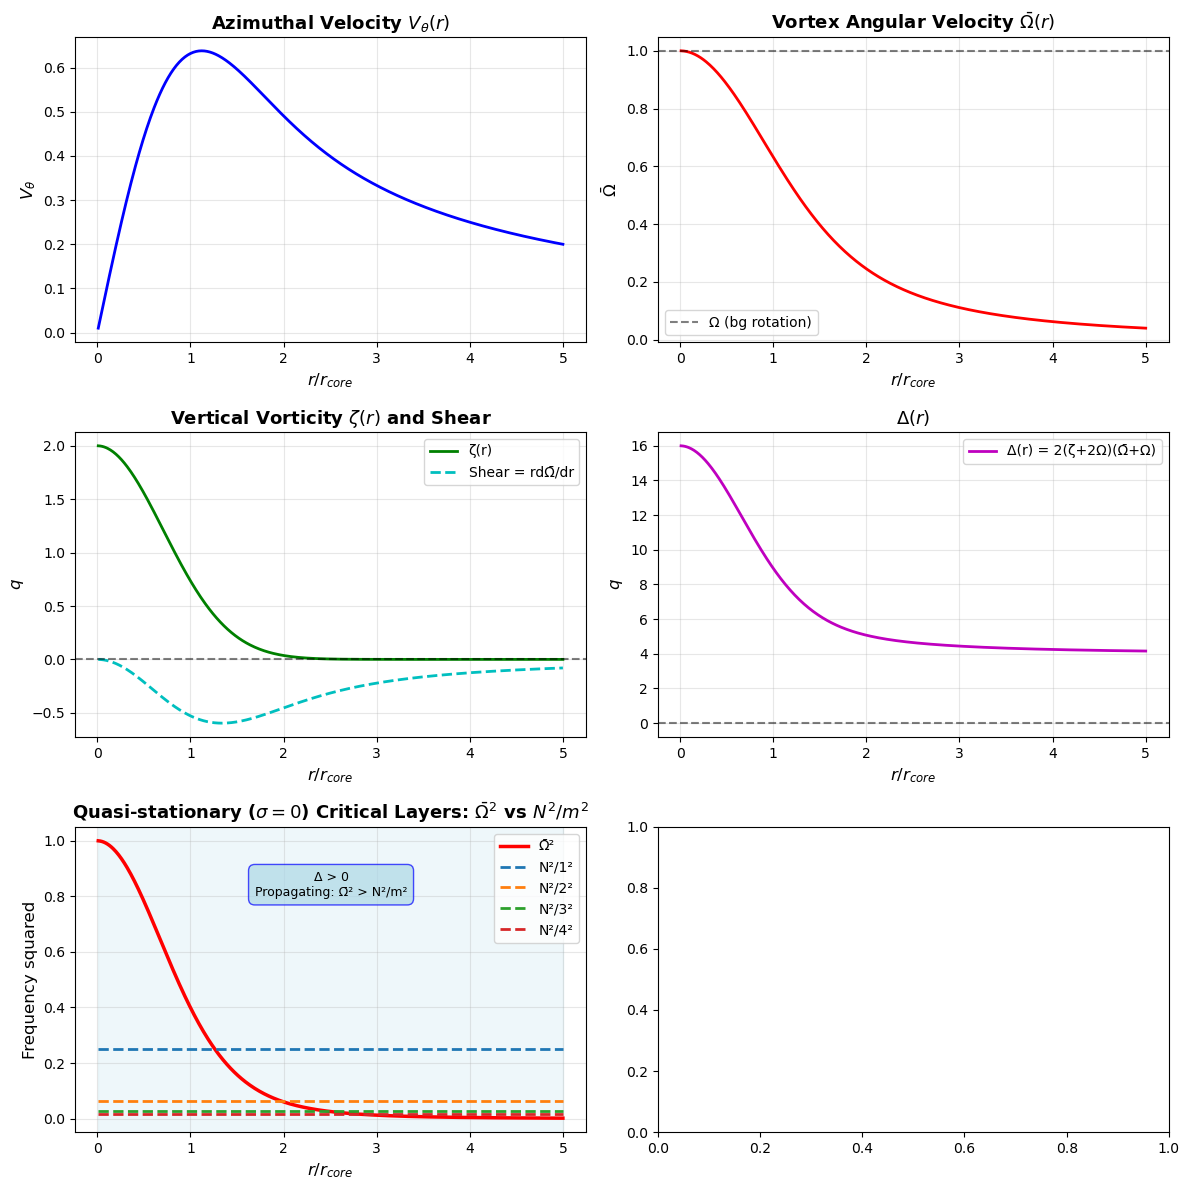

In [5]:
# Create vortex with background rotation
vortex = LambOseenVortex(V_max, r_core, Omega_bg)

# Visualize profiles
r_plot = np.linspace(0.01, 5*r_core, 500)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# V_theta
axes[0,0].plot(r_plot/r_core, vortex.V_theta(r_plot), 'b-', linewidth=2)
axes[0,0].set_xlabel('$r / r_{core}$', fontsize=12)
axes[0,0].set_ylabel('$V_\\theta$', fontsize=12)
axes[0,0].set_title('Azimuthal Velocity $V_\\theta(r)$', fontsize=13, fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# Omega_bar (vortex angular velocity)
axes[0,1].plot(r_plot/r_core, vortex.Omega_bar(r_plot), 'r-', linewidth=2)
axes[0,1].axhline(Omega_bg, color='k', linestyle='--', alpha=0.5, label=f'Ω (bg rotation)')
axes[0,1].set_xlabel('$r / r_{core}$', fontsize=12)
axes[0,1].set_ylabel('$\\bar{\\Omega}$', fontsize=12)
axes[0,1].set_title('Vortex Angular Velocity $\\bar{\\Omega}(r)$', fontsize=13, fontweight='bold')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend(fontsize=10)

# zeta (vertical vorticity)
axes[1,0].plot(r_plot/r_core, vortex.zeta(r_plot), 'g-', linewidth=2, label='ζ(r)')
axes[1,0].plot(r_plot/r_core, vortex.shear(r_plot), 'c--', linewidth=2, label='Shear = rdΩ̄/dr')
axes[1,0].set_xlabel('$r / r_{core}$', fontsize=12)
axes[1,0].set_ylabel('$q$', fontsize=12)
axes[1,0].set_title('Vertical Vorticity $\\zeta(r)$ and Shear', fontsize=13, fontweight='bold')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[1,0].legend(fontsize=10)

# Delta
axes[1,1].plot(r_plot/r_core, vortex.Delta(r_plot), 'm-', linewidth=2, label='Δ(r) = 2(ζ+2Ω)(Ω̄+Ω)')
axes[1,1].set_xlabel('$r / r_{core}$', fontsize=12)
axes[1,1].set_ylabel('$q$', fontsize=12)
axes[1,1].set_title('$\\Delta(r)$', fontsize=13, fontweight='bold')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[1,1].legend(fontsize=10)

# Omega_bar^2 vs N^2/m^2 line with Delta sign regions
Delta_vals = vortex.Delta(r_plot)
axes[2,0].plot(r_plot/r_core, (vortex.Omega_bar(r_plot))**2, 'r-', linewidth=2.5, label='Ω̄²')
for m in range(1, 5):
    axes[2,0].plot(r_plot/r_core, (N/m)**2 * np.ones_like(r_plot), '--', linewidth=2, label=f'N²/{m}²')

# Shade regions based on sign of Delta
Delta_positive = Delta_vals > 0
Delta_negative = Delta_vals < 0
if np.any(Delta_positive):
    mask_padded = np.concatenate([[False], Delta_positive, [False]])
    diff_mask = np.diff(mask_padded.astype(int))
    starts = np.where(diff_mask == 1)[0]
    ends = np.where(diff_mask == -1)[0]
    for start_idx, end_idx in zip(starts, ends):
        axes[2,0].axvspan(r_plot[start_idx]/r_core, r_plot[end_idx-1]/r_core, 
                         color='lightblue', alpha=0.2, zorder=0)
if np.any(Delta_negative):
    mask_padded = np.concatenate([[False], Delta_negative, [False]])
    diff_mask = np.diff(mask_padded.astype(int))
    starts = np.where(diff_mask == 1)[0]
    ends = np.where(diff_mask == -1)[0]
    for start_idx, end_idx in zip(starts, ends):
        axes[2,0].axvspan(r_plot[start_idx]/r_core, r_plot[end_idx-1]/r_core, 
                         color='lightyellow', alpha=0.3, zorder=0)
if np.any(Delta_positive):
    idx_pos = np.where(Delta_positive)[0][len(np.where(Delta_positive)[0])//2]
    r_pos = r_plot[idx_pos] / r_core
    y_pos = axes[2,0].get_ylim()[1] * 0.85
    axes[2,0].text(r_pos, y_pos, 'Δ > 0\nPropagating: Ω̄² > N²/m²', 
                   fontsize=9, ha='center', va='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', 
                            edgecolor='blue', alpha=0.7))
if np.any(Delta_negative):
    idx_neg = np.where(Delta_negative)[0][len(np.where(Delta_negative)[0])//2]
    r_neg = r_plot[idx_neg] / r_core
    y_neg = axes[2,0].get_ylim()[1] * 0.85
    axes[2,0].text(r_neg, y_neg, 'Δ < 0\nPropagating: Ω̄² < N²/m²', 
                   fontsize=9, ha='center', va='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', 
                            edgecolor='orange', alpha=0.7))

axes[2,0].set_title('Quasi-stationary ($\\sigma=0$) Critical Layers: $\\bar{\\Omega}^2$ vs $N^2/m^2$', 
                    fontsize=13, fontweight='bold')
axes[2,0].legend(fontsize=10, loc='upper right')
axes[2,0].set_xlabel('$r / r_{core}$', fontsize=12)
axes[2,0].set_ylabel('Frequency squared', fontsize=12)
axes[2,0].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Cylindrical Ray Tracer Initialized:
  V_max = 1.0000, r_core = 1.0000
  Omega (background rotation) = 1.0000
  N (stratification) = 0.5000
  m (azimuthal mode) = 1
  kz (vertical wavenumber) = 1.0000
  r_max = 5.0000
m=1: 374/500 evanescent points (74.8%)
  1 evanescent region(s):
    Region 1: r/r_core ∈ [1.270, 5.000] (width = 3.730)
Cylindrical Ray Tracer Initialized:
  V_max = 1.0000, r_core = 1.0000
  Omega (background rotation) = 1.0000
  N (stratification) = 0.5000
  m (azimuthal mode) = 2
  kz (vertical wavenumber) = 1.0000
  r_max = 5.0000
m=2: 302/500 evanescent points (60.4%)
  1 evanescent region(s):
    Region 1: r/r_core ∈ [1.990, 5.000] (width = 3.010)
Cylindrical Ray Tracer Initialized:
  V_max = 1.0000, r_core = 1.0000
  Omega (background rotation) = 1.0000
  N (stratification) = 0.5000
  m (azimuthal mode) = 3
  kz (vertical wavenumber) = 1.0000
  r_max = 5.0000
m=3: 256/500 evanescent points (51.2%)
  1 evanescent region(s):
    Region 1: r/r_core ∈ [2.450, 5.000] (w

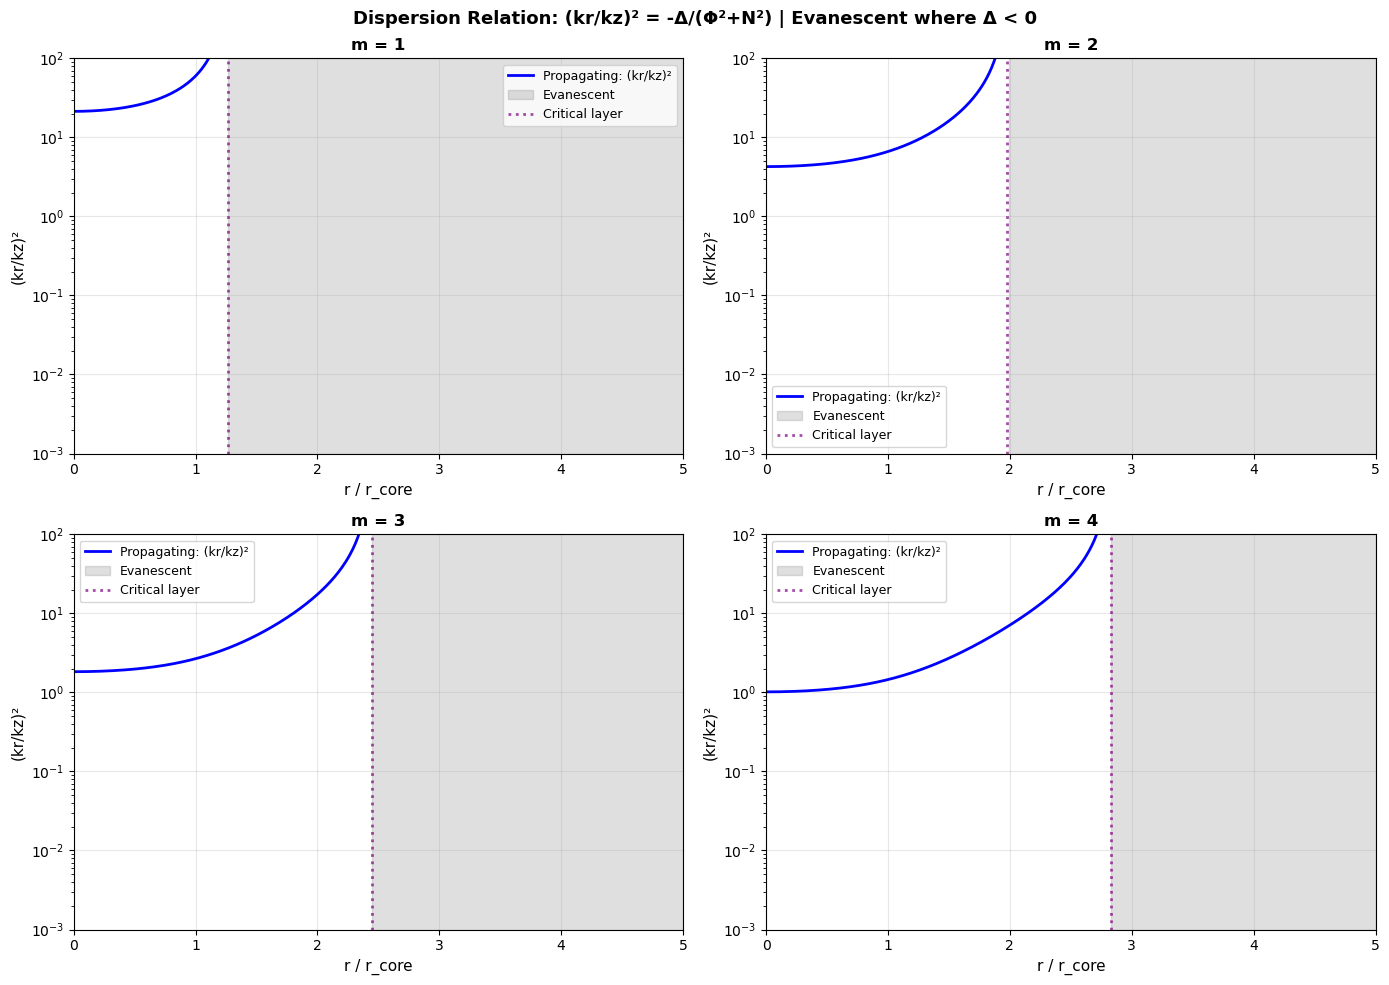

In [6]:
# Visualize dispersion relation: (kr/kz)² vs r for different m values
r_max_domain = 5 * r_core
r_scan = np.linspace(0.01, r_max_domain, 500)
kz = 1.0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, m_val in enumerate([1, 2, 3, 4]):
    ax = axes[idx // 2, idx % 2]
    temp_tracer = CylindricalRayTracer(vortex, N, m_val, kz, r_max_domain)
    
    # Compute dispersion at each r
    kr_sq_over_kz_sq = []
    is_propagating = []
    
    for r in r_scan:
        disp = temp_tracer.compute_dispersion(r)
        if disp['is_propagating'] and disp['kr_sq'] is not None:
            kr_sq_over_kz_sq.append(disp['kr_sq'] / kz**2)
            is_propagating.append(True)
        else:
            kr_sq_over_kz_sq.append(np.nan)
            is_propagating.append(False)
    
    # Plot propagating regions
    ax.plot(r_scan/r_core, np.array(kr_sq_over_kz_sq), 'b-', linewidth=2, 
            label='Propagating: (kr/kz)²')
    
    # Find and shade ALL evanescent regions
    evanescent_mask = ~np.array(is_propagating)
    n_evanescent = np.sum(evanescent_mask)
    print(f"m={m_val}: {n_evanescent}/{len(r_scan)} evanescent points ({100*n_evanescent/len(r_scan):.1f}%)")
    
    if np.any(evanescent_mask):
        # Detect region boundaries: transitions from propagating to evanescent
        mask_padded = np.concatenate([[False], evanescent_mask, [False]])
        diff_mask = np.diff(mask_padded.astype(int))
        starts = np.where(diff_mask == 1)[0]  # False -> True transitions
        ends = np.where(diff_mask == -1)[0]   # True -> False transitions
        
        print(f"  {len(starts)} evanescent region(s):")
        for i, (start_idx, end_idx) in enumerate(zip(starts, ends)):
            r_start = r_scan[start_idx] / r_core
            r_end = r_scan[end_idx - 1] / r_core  # end_idx points past last evanescent point
            width = r_end - r_start
            print(f"    Region {i+1}: r/r_core ∈ [{r_start:.3f}, {r_end:.3f}] (width = {width:.3f})")
            
            # Shade region (expand narrow regions for visibility)
            if width < 0.05:
                r_mid = (r_start + r_end) / 2
                r_start_plot, r_end_plot = r_mid - 0.025, r_mid + 0.025
            else:
                r_start_plot, r_end_plot = r_start, r_end
            
            ax.axvspan(r_start_plot, r_end_plot, color='gray', alpha=0.25, zorder=0,
                       label='Evanescent' if i == 0 else '')
    
    # Mark critical layers
    r_crit_m = temp_tracer.find_critical_layers()
    for i, rc in enumerate(r_crit_m):
        ax.axvline(rc/r_core, color='purple', linestyle=':', linewidth=2, alpha=0.7,
                   label='Critical layer' if i == 0 else '')
    
    # Formatting
    ax.set_xlabel('r / r_core', fontsize=11)
    ax.set_ylabel('(kr/kz)²', fontsize=11)
    ax.set_title(f'm = {m_val}', fontsize=12, fontweight='bold')
    ax.set_xlim(0, r_max_domain/r_core)
    ax.set_yscale('log')
    ax.set_ylim(1e-3, 1e2)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='best')

plt.suptitle('Dispersion Relation: (kr/kz)² = -Δ/(Φ²+N²) | Evanescent where Δ < 0', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Trace Single Ray (Both Modes)

Cylindrical Ray Tracer Initialized:
  V_max = 1.0000, r_core = 1.0000
  Omega (background rotation) = 1.0000
  N (stratification) = 0.5000
  m (azimuthal mode) = 2
  kz (vertical wavenumber) = 1.0000
  r_max = 5.0000

Critical layers found at r/r_core = [1.97953977]
Evanescent regions found: 123 points
  r/r_core ∈ [1.996, 5.000]

Wave parameters:
  m = 2
  kz = 1.0
  Starting point: r0 = 0.5517, z0 = 0.0000
  Retained term: 2.7129e+01
  Neglected term 1 (m*dΩ̄/dr/Φ): 5.1525e-01
  Neglected term 2 (m²/r²): 1.3631e+01
  Retained term: 2.7129e+01
  Neglected term 1 (m*dΩ̄/dr/Φ): 5.1525e-01
  Neglected term 2 (m²/r²): 1.3631e+01

Mode 1 (+kr): 137 points, r ∈ [0.542, 1.902], z ∈ [-0.022, 5.065]
  kr range: [2.1801, 10.7603]
Mode 2 (−kr): 137 points, r ∈ [0.542, 1.902], z ∈ [-5.065, 0.022]
  kr range: [-10.7603, -2.1801]


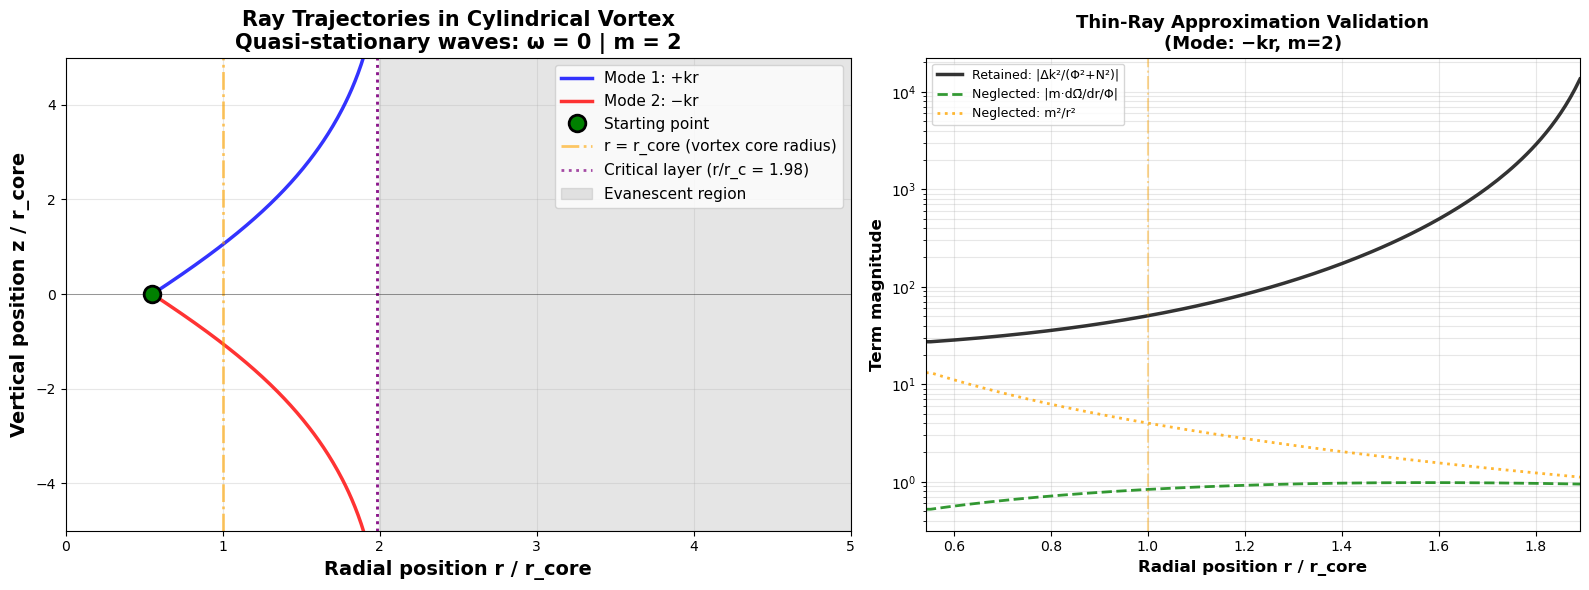

In [7]:
# Wave parameters
m = 2  # Azimuthal mode number
kz = 1.0  # Vertical wavenumber

# Initialize ray tracer (use r_max_domain and kz from above)
tracer = CylindricalRayTracer(vortex, N, m, kz, r_max_domain)

# Find critical layers
r_crit = tracer.find_critical_layers()
print(f"\nCritical layers found at r/r_core = {r_crit/r_core}")

# Check evanescent regions
r_check = np.linspace(0.1, r_max_domain, 200)
evanescent_regions = []
for r in r_check:
    disp = tracer.compute_dispersion(r)
    if not disp['is_propagating']:
        evanescent_regions.append(r)

if len(evanescent_regions) > 0:
    r_evan = np.array(evanescent_regions)
    print(f"Evanescent regions found: {len(r_evan)} points")
    print(f"  r/r_core ∈ [{r_evan.min()/r_core:.3f}, {r_evan.max()/r_core:.3f}]")
else:
    print("No evanescent regions found")

# Starting point
# r0 = 0.5 * r_core
r0 = find_valid_starting_radius(tracer, r_min=0.1, r_max=r_max_domain)
z0 = 0.0

print(f"\nWave parameters:")
print(f"  m = {m}")
print(f"  kz = {kz}")
print(f"  Starting point: r0 = {r0:.4f}, z0 = {z0:.4f}")

# Mode 1: kr > 0 (positive radial wavenumber)
r1, z1, kr1, diag1 = tracer.trace_ray(r0, z0, sign_choice=+1, dr=0.01, check_approximation=True)

# Mode 2: kr < 0 (negative radial wavenumber)
r2, z2, kr2, diag2 = tracer.trace_ray(r0, z0, sign_choice=-1, dr=0.01, check_approximation=True)

print(f"\nMode 1 (+kr): {len(z1)} points, r ∈ [{r1.min():.3f}, {r1.max():.3f}], z ∈ [{z1.min():.3f}, {z1.max():.3f}]")
print(f"  kr range: [{kr1.min():.4f}, {kr1.max():.4f}]")
print(f"Mode 2 (−kr): {len(z2)} points, r ∈ [{r2.min():.3f}, {r2.max():.3f}], z ∈ [{z2.min():.3f}, {z2.max():.3f}]")
print(f"  kr range: [{kr2.min():.4f}, {kr2.max():.4f}]")

fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])

# Left subplot: Ray trajectories
ax = fig.add_subplot(gs[0])

# Plot trajectories (normalized)
ax.plot(r1/r_core, z1/r_core, 'b-', linewidth=2.5, label='Mode 1: +kr', alpha=0.8)
ax.plot(r2/r_core, z2/r_core, 'r-', linewidth=2.5, label='Mode 2: −kr', alpha=0.8)

# Mark starting point
ax.plot(r0/r_core, z0/r_core, 'go', markersize=12, label='Starting point', zorder=10, 
        markeredgecolor='black', markeredgewidth=2)

# Mark vortex core radius with vertical line (vortex is columnar, not a circle!)
ax.axvline(1.0, color='orange', linestyle='-.', linewidth=2, alpha=0.6, 
           label='r = r_core (vortex core radius)')

# Mark critical layers
for rc in r_crit:
    ax.axvline(rc/r_core, color='purple', linestyle=':', linewidth=2, alpha=0.7)
if len(r_crit) > 0:
    ax.axvline(r_crit[0]/r_core, color='purple', linestyle=':', linewidth=2, alpha=0.7,
               label=f'Critical layer (r/r_c = {r_crit[0]/r_core:.2f})')

# Shade evanescent regions if they exist
if len(evanescent_regions) > 0:
    r_evan_norm = np.array(evanescent_regions) / r_core
    # Find contiguous regions
    dr_check = r_check[1] - r_check[0]
    gaps = np.where(np.diff(r_evan_norm) > 2*dr_check/r_core)[0]
    
    if len(gaps) == 0:
        ax.axvspan(r_evan_norm.min(), r_evan_norm.max(), color='gray', alpha=0.2, 
                   label='Evanescent region')
    else:
        # Multiple disjoint regions
        starts = [0] + (gaps + 1).tolist()
        ends = gaps.tolist() + [len(r_evan_norm)-1]
        for i, (start, end) in enumerate(zip(starts, ends)):
            ax.axvspan(r_evan_norm[start], r_evan_norm[end], color='gray', alpha=0.2,
                       label='Evanescent region' if i == 0 else '')

# Formatting
ax.set_xlabel('Radial position r / r_core', fontsize=14, fontweight='bold')
ax.set_ylabel('Vertical position z / r_core', fontsize=14, fontweight='bold')
ax.set_title('Ray Trajectories in Cylindrical Vortex\n'
             f'Quasi-stationary waves: ω = 0 | m = {m}', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, r_max_domain/r_core)
ax.set_ylim(-r_max_domain/r_core, r_max_domain/r_core)
ax.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)

# Right subplot: Thin-ray approximation validation
ax2 = fig.add_subplot(gs[1])

# Plot terms for Mode 1 (choose the longer trajectory)
if len(diag1['retained_term']) > len(diag2['retained_term']):
    diag = diag1
    mode_label = '+kr'
    color = 'blue'
else:
    diag = diag2
    mode_label = '−kr'
    color = 'red'

r_diag = diag['r_values'] / r_core

ax2.semilogy(r_diag, diag['retained_term'], 'k-', linewidth=2.5, 
             label='Retained: |Δk²/(Φ²+N²)|', alpha=0.8)
ax2.semilogy(r_diag, diag['neglected_term1'], 'g--', linewidth=2, 
             label='Neglected: |m·dΩ̄/dr/Φ|', alpha=0.8)
ax2.semilogy(r_diag, diag['neglected_term2'], 'orange', linestyle=':', linewidth=2, 
             label='Neglected: m²/r²', alpha=0.8)

# Mark vortex core
ax2.axvline(1.0, color='orange', linestyle='-.', linewidth=1.5, alpha=0.4)

ax2.set_xlabel('Radial position r / r_core', fontsize=12, fontweight='bold')
ax2.set_ylabel('Term magnitude', fontsize=12, fontweight='bold')
ax2.set_title(f'Thin-Ray Approximation Validation\n(Mode: {mode_label}, m={m})', 
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9, loc='best')
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xlim(r_diag.min(), r_diag.max())

plt.tight_layout()
plt.show()

## 5. Multiple Rays with Different Azimuthal Mode Numbers

Trace multiple rays with different $m$ values to see how azimuthal structure affects ray paths.

In [8]:
# Different m values (integer azimuthal mode numbers)
m_values = [1, 2, 3, 4, 5, 6]
kz = 1.0  # Fixed vertical wavenumber
r_max_domain = 10 * r_core

trajectories_pos = []  # kr > 0 branch
trajectories_neg = []  # kr < 0 branch
critical_layers = {}  # Store critical layer locations for each m
starting_positions = {}  # Store starting positions for each m
z_start = 0.0

for m in m_values:
    # Create tracer for this m
    temp_tracer = CylindricalRayTracer(vortex, N, m, kz, r_max_domain)
    
    # Find critical layers
    r_crit_m = temp_tracer.find_critical_layers()
    critical_layers[m] = r_crit_m
    
    # Find valid starting radius
    r_start = find_valid_starting_radius(temp_tracer, r_min=0.1, r_max=r_max_domain)
    
    if r_start is None:
        print(f"m = {m}: No valid region found (thin-ray approximation breaks down everywhere or fully evanescent). SKIPPING.")
        continue
    
    starting_positions[m] = r_start
    print(f"m = {m}: Starting at r/r_core = {r_start/r_core:.3f}")
    
    # Mode 1: kr > 0
    r_pos, z_pos, kr_pos, diag_pos = temp_tracer.trace_ray(r_start, z_start, sign_choice=+1, dr=0.01, check_approximation=True)
    trajectories_pos.append({'r': r_pos, 'z': z_pos, 'kr': kr_pos, 'diag': diag_pos, 'm': m})
    
    # Mode 2: kr < 0
    r_neg, z_neg, kr_neg, diag_neg = temp_tracer.trace_ray(r_start, z_start, sign_choice=-1, dr=0.01, check_approximation=True)
    trajectories_neg.append({'r': r_neg, 'z': z_neg, 'kr': kr_neg, 'diag': diag_neg, 'm': m})
    
    print(f"  Mode 1 (+kr): {len(z_pos)} points, r ∈ [{r_pos.min()/r_core:.3f}, {r_pos.max()/r_core:.3f}]")
    print(f"  Mode 2 (−kr): {len(z_neg)} points, r ∈ [{r_neg.min()/r_core:.3f}, {r_neg.max()/r_core:.3f}]")
    if len(r_crit_m) > 0:
        print(f"  Critical layers at r/r_c = {r_crit_m/r_core}")

Cylindrical Ray Tracer Initialized:
  V_max = 1.0000, r_core = 1.0000
  Omega (background rotation) = 1.0000
  N (stratification) = 0.5000
  m (azimuthal mode) = 1
  kz (vertical wavenumber) = 1.0000
  r_max = 10.0000
m = 1: Starting at r/r_core = 0.100
  Retained term: 4.7841e+02
  Neglected term 1 (m*dΩ̄/dr/Φ): 5.9964e-02
  Neglected term 2 (m²/r²): 2.7778e+02
  Retained term: 4.7841e+02
  Neglected term 1 (m*dΩ̄/dr/Φ): 5.9964e-02
  Neglected term 2 (m²/r²): 2.7778e+02
  Mode 1 (+kr): 122 points, r ∈ [0.060, 1.270]
  Mode 2 (−kr): 122 points, r ∈ [0.060, 1.270]
  Critical layers at r/r_c = [1.26437219]
Cylindrical Ray Tracer Initialized:
  V_max = 1.0000, r_core = 1.0000
  Omega (background rotation) = 1.0000
  N (stratification) = 0.5000
  m (azimuthal mode) = 2
  kz (vertical wavenumber) = 1.0000
  r_max = 10.0000
m = 2: Starting at r/r_core = 0.556
  Retained term: 2.7017e+01
  Neglected term 1 (m*dΩ̄/dr/Φ): 5.1064e-01
  Neglected term 2 (m²/r²): 1.3907e+01
  Retained term: 2.7017

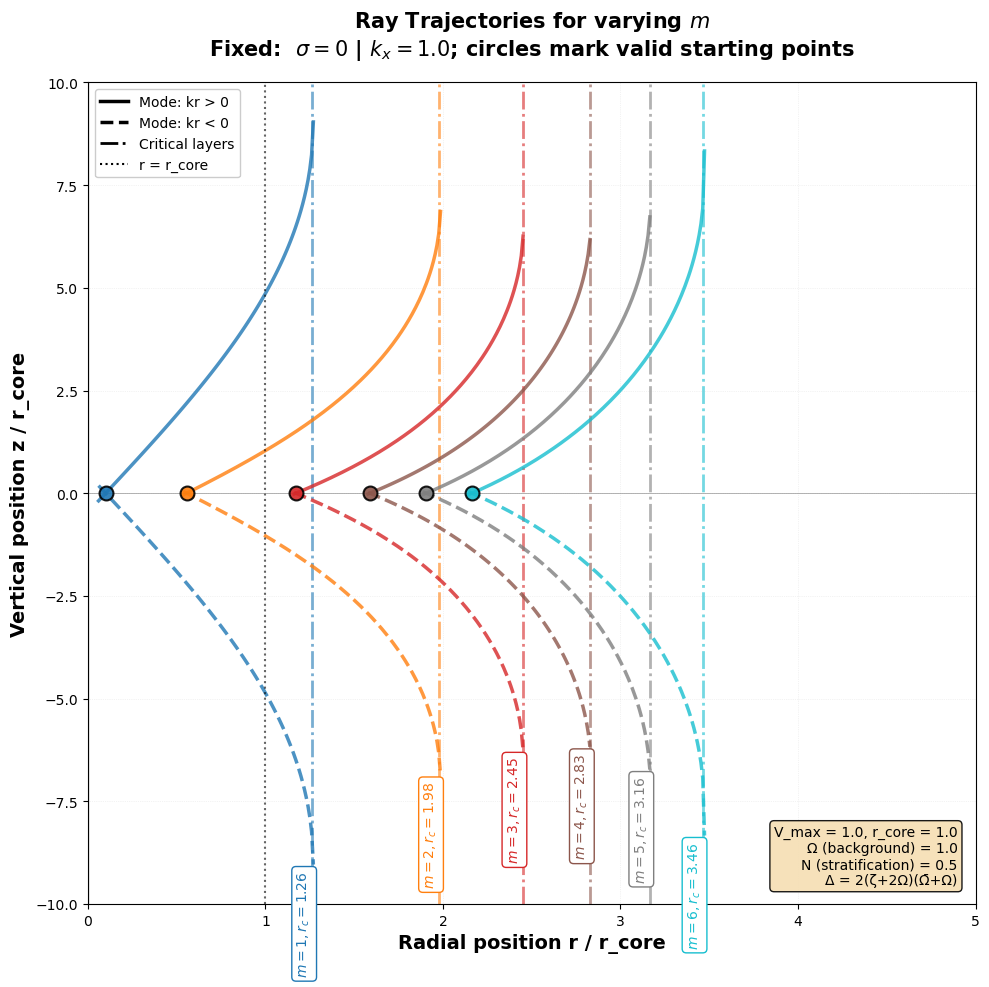

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

# Generate colors dynamically based on number of trajectories
n_trajectories = len(trajectories_pos)
if n_trajectories <= 4:
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
else:
    # Use colormap for more than 4 values
    cmap = plt.cm.get_cmap('tab10')
    colors = [cmap(i) for i in np.linspace(0, 0.9, n_trajectories)]

# Plot trajectories for each m
for i, (traj_pos, traj_neg) in enumerate(zip(trajectories_pos, trajectories_neg)):
    m_val = traj_pos['m']
    color = colors[i]
    
    # Mode 1: solid line
    ax.plot(traj_pos['r']/r_core, traj_pos['z']/r_core, color=color, linestyle='-', 
            linewidth=2.5, alpha=0.8)
    
    # Mode 2: dashed line
    ax.plot(traj_neg['r']/r_core, traj_neg['z']/r_core, color=color, linestyle='--', 
            linewidth=2.5, alpha=0.8)
    
    # Mark critical layers for this m (use black lines, label with textbox)
    if m_val in critical_layers and len(critical_layers[m_val]) > 0:
        for rc in critical_layers[m_val]:
            ax.axvline(rc/r_core, color=colors[i], linestyle='-.', linewidth=2, alpha=0.6, zorder=1)
            
            # Add text label near critical layer with m and rc value
            ax.text(rc/r_core, np.min(traj_neg['z'])/r_core-0.15, 
                    f'$m={m_val}, r_c={rc/r_core:.2f}$', 
                    fontsize=10, color=color, fontweight='bold', rotation=90, 
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=1.0))
    
    # Mark starting point for this m
    if m_val in starting_positions:
        ax.plot(starting_positions[m_val]/r_core, 0.0, 'o', color=color, markersize=10, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=10, alpha=0.9)

# Mark vortex core radius with black vertical line
ax.axvline(1.0, color='black', linestyle=':', linewidth=1.5, alpha=0.6)

# Axis at r=0 and z=0
ax.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

# Legend - show line styles only (in black)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', linewidth=2.5, linestyle='-', label='Mode: kr > 0'),
    Line2D([0], [0], color='black', linewidth=2.5, linestyle='--', label='Mode: kr < 0'),
    Line2D([0], [0], color='black', linewidth=2, linestyle='-.', label='Critical layers'),
    Line2D([0], [0], color='black', linewidth=1.5, linestyle=':', label='r = r_core')
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper left', framealpha=1.0)

# Formatting
ax.set_xlabel('Radial position r / r_core', fontsize=14, fontweight='bold')
ax.set_ylabel('Vertical position z / r_core', fontsize=14, fontweight='bold')
ax.set_title(f"Ray Trajectories for varying $m$\n"
             f"Fixed:  $\sigma = 0$ | $k_x = 1.0$; circles mark valid starting points", 
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
ax.set_xlim(0, 5) #r_max_domain/r_core)
ax.set_ylim(-r_max_domain/r_core, r_max_domain/r_core)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='k', linestyle='-', linewidth=1.5, alpha=0.8)

# Parameter text
param_text = f'V_max = {V_max}, r_core = {r_core}\nΩ (background) = {Omega_bg}\nN (stratification) = {N}\nΔ = 2(ζ+2Ω)(Ω̄+Ω)'
ax.text(0.98, 0.02, param_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

plt.tight_layout()
plt.show()